In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [102]:
df=pd.read_csv("20260202 Dataset 2 (v8).xlsx - dataset V8.csv")

In [103]:
df[df['status'] == 'CLOSE']

,dataset,id,file_number,case,with companion,case type,case status,initial_type,current_type,status,...,hist_status_1,hist_date_1,hist_status_2,hist_date_2,hist_status_3,hist_date_3,hist_status_4,hist_date_4,hist_status_5,hist_date_5
0,claims,13US-212772,28006621,28006621,NO,SUIT,CLOSE,SUIT,SUIT,CLOSE,...,SUIT,12/18/2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,claims,13US-212773,29000200,29000200,NO,SUIT,CLOSE,SUIT,SUIT,CLOSE,...,SUIT,1/5/2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,claims,13US-212774,29001340,29001340,NO,SUIT,CLOSE,SUIT,SUIT,CLOSE,...,SUIT,12/18/2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,claims,13US-212775,29001341,29001341,NO,SUIT,CLOSE,SUIT,SUIT,CLOSE,...,SUIT,12/18/2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,claims,13US-212776,10426-01,10426,NO,SUIT,CLOSE,SUIT,SUIT,CLOSE,...,SUIT,3/8/2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3621,actions,13US-214272,56697-01,56697,NO,PCE,CLOSE,PCE,PCE,CLOSE,...,PCE,12/26/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3622,actions,13US-214265,56698-01,56698,NO,PCE,CLOSE,PCE,PCE,CLOSE,...,PCE,12/31/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3623,actions,13US-214307,56699-01,56699,NO,PCE,CLOSE,PCE,PCE,CLOSE,...,PCE,12/30/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3624,actions,13US-214264,56700-01,56700,NO,PCE,CLOSE,PCE,PCE,CLOSE,...,PCE,12/31/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [104]:
df= df[df['current_type'] != 'PCE']


In [105]:
is_claim = df['current_type'] == 'CLAIM'
has_lawfirm = df['defendant_lf'].notna()
df = df[~is_claim | has_lawfirm]


In [106]:
# --- Config ---
selected_state  = 'Pennsylvania'   # change state name here
selected_county = None             # set to e.g. 'Allegheny County' or None for all counties


In [107]:
df['closed_loss'] = pd.to_datetime(df['closed_loss'], format='%m/%d/%Y', errors='coerce')
df['date_open'] = pd.to_datetime(df['date_open'], format='%m/%d/%Y', errors='coerce')
df['claim_length'] = (df['closed_loss'] - df['date_open']).dt.days

In [108]:
# Filter by state and optional county
state_df = df[
    (df['state'] == selected_state) &
    df['defendant_lf'].notna() &
    df['claim_length'].notna()
]

In [109]:
if selected_county:
    state_df = state_df[state_df['county'] == selected_county]


In [110]:
# Aggregate: top 15 law firms by total expense
agg = (
    state_df.groupby('defendant_lf')['claim_length']
    .median()
    .sort_values(ascending=False)
    .head(15)
)

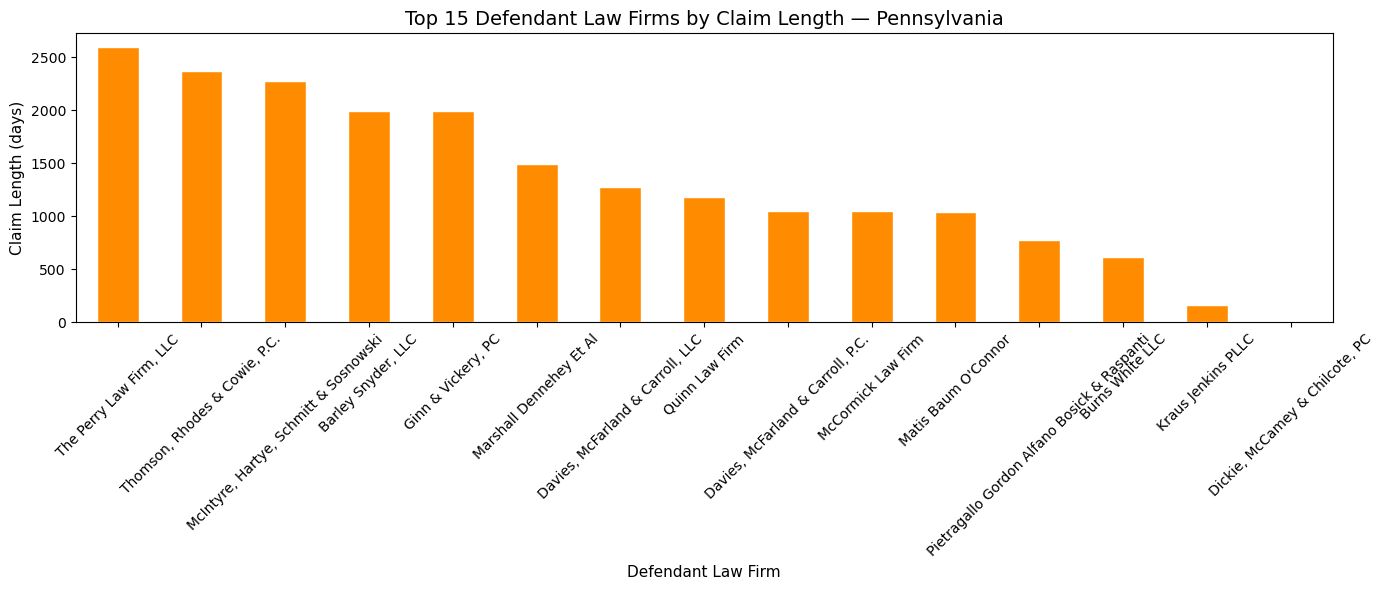


State: Pennsylvania  |  County: All  |  Law firms shown: 15


In [111]:
# Plot
location_label = f'{selected_county}, {selected_state}' if selected_county else selected_state
fig, ax = plt.subplots(figsize=(14, 6))
agg.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')

ax.set_title(f'Top 15 Defendant Law Firms by Claim Length — {location_label}', fontsize=14)
ax.set_xlabel('Defendant Law Firm', fontsize=11)
ax.set_ylabel('Claim Length (days)', fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f'\nState: {selected_state}  |  County: {selected_county or "All"}  |  Law firms shown: {len(agg)}')